In [1]:
# Import requisite modules
from BASIS.modules import vis, imutils
import numpy as np
import matplotlib.pyplot as plt
from BASIS.models import base
import ehtim as eh
from BASIS.modules import likelihood


/datasets/work/sa-closures-ml/work/BASIS/.basis/lib/python3.11/site-packages/ehtim/__init__.py:57: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Welcome to eht-imaging! v 1.3.2 



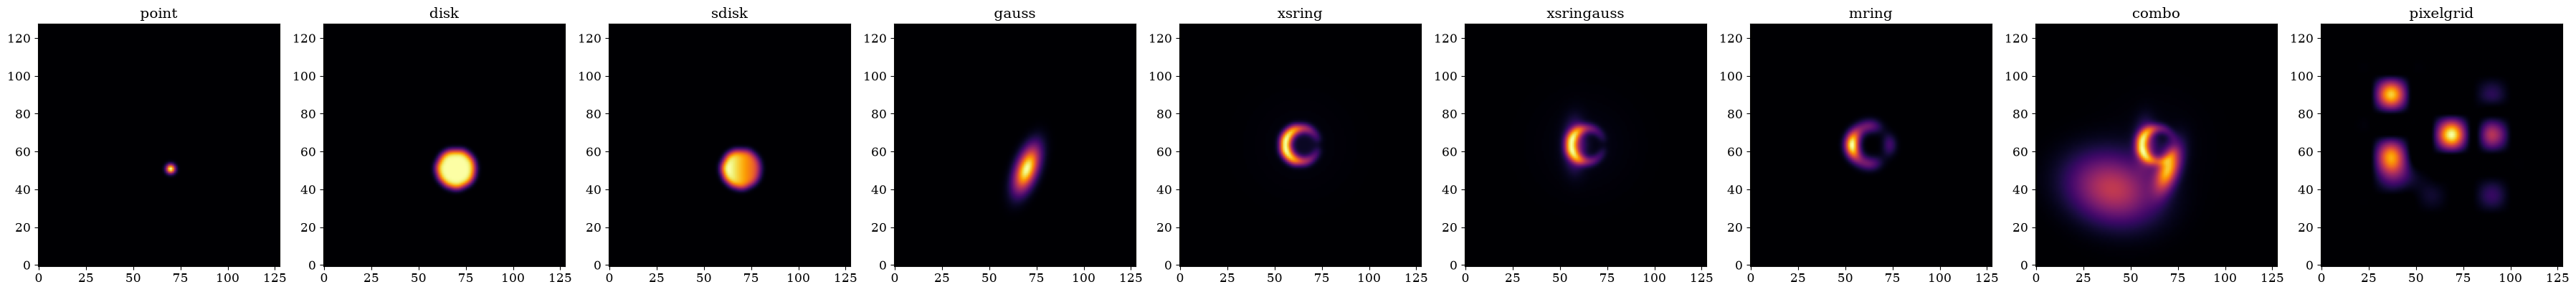

In [2]:
# Define models

fov = 300 # Field of view (uas)
imgdim = 128 # Image dimension (pixels)

xpoint = base.BaseModel(model_list=['point'], fov=fov, dim=imgdim)
xdisk = base.BaseModel(model_list=['disk'], fov=fov, dim=imgdim)
sdisk = base.BaseModel(model_list=['sdisk'], fov=fov, dim=imgdim)
xgauss = base.BaseModel(model_list=['gauss'], fov=fov, dim=imgdim)
xsr = base.BaseModel(model_list=['xsring'], fov=fov, dim=imgdim)
xsrg = base.BaseModel(model_list=['xsringauss'], fov=fov, dim=imgdim)
mrmodel = base.BaseModel(model_list=['mring4'], fov=fov, dim=imgdim)
combo = base.BaseModel(model_list=['xsringauss', 'gauss', 'gauss'], fov=fov, dim=imgdim, 
                       randomise_params=[False, False, True], random_seed=42)
grid = base.BaseModel(model_list=['pixelgrid'], fov=fov, dim=imgdim, randomise_params=[False])

models = {'point': xpoint, 'disk': xdisk, 'sdisk': sdisk, 'gauss': xgauss, 'xsring': xsr, 'xsringauss': xsrg, 'mring': mrmodel, 'combo': combo, 'pixelgrid': grid}

fig, axs = plt.subplots(1,len(models),figsize=(4*len(models),4))
for model in models:
    img =  models[model].sky_map()
    axs[list(models.keys()).index(model)].imshow(img, origin='lower', cmap='inferno')
    axs[list(models.keys()).index(model)].set_title(model)
plt.tight_layout()


Loading uvfits:  ../data/uvfits/SR1_M87_2017_101_hilo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Producing clean visibilities from image with fast FT . . . 


/datasets/work/sa-closures-ml/work/BASIS/.basis/lib/python3.11/site-packages/ehtim/io/load.py:1423: RuntimeWarning: invalid value encountered in multiply
  rl = (np.nansum(np.nansum(rl_2d * rlweight, axis=2), axis=1) /
/datasets/work/sa-closures-ml/work/BASIS/.basis/lib/python3.11/site-packages/ehtim/io/load.py:1423: RuntimeWarning: invalid value encountered in divide
  rl = (np.nansum(np.nansum(rl_2d * rlweight, axis=2), axis=1) /
/datasets/work/sa-closures-ml/work/BASIS/.basis/lib/python3.11/site-packages/ehtim/io/load.py:1425: RuntimeWarning: invalid value encountered in multiply
  lr = (np.nansum(np.nansum(lr_2d * lrweight, axis=2), axis=1) /
/datasets/work/sa-closures-ml/work/BASIS/.basis/lib/python3.11/site-packages/ehtim/io/load.py:1425: RuntimeWarning: invalid value encountered in divide
  lr = (np.nansum(np.nansum(lr_2d * lrweight, axis=2), axis=1) /


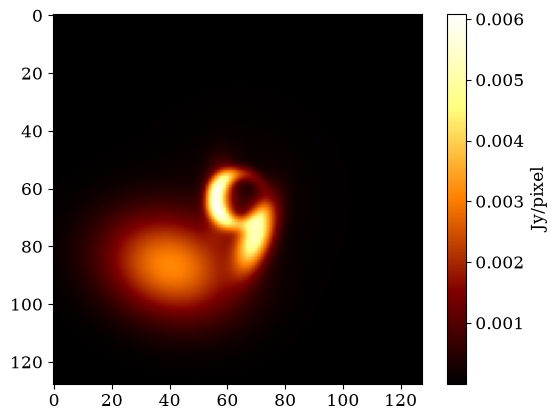

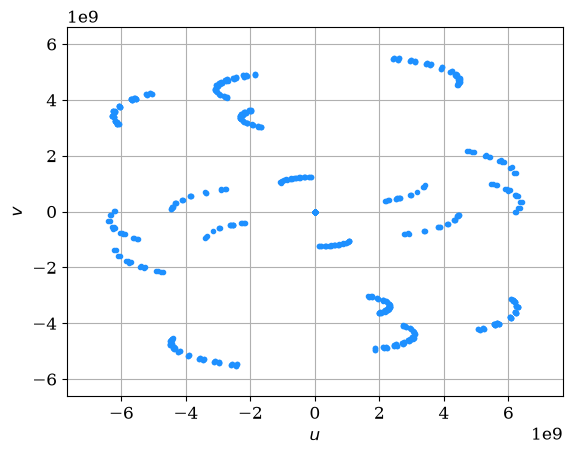

/tmp/ipykernel_20775/656482536.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axs[0].scatter(uvdist, np.abs(anaVis), color='red', s=5, label='Analytic')
/tmp/ipykernel_20775/656482536.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axs[0].scatter(uvdist, np.abs(numVis), marker='x', color='green', s=1, label='DFT')


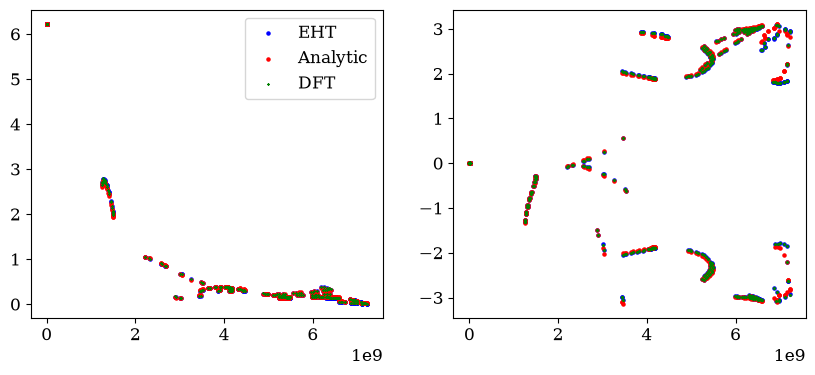

In [3]:
# Compare analytical and numerical visibilities
model_choice = combo

eh_img = eh.image.make_empty(imgdim, fov=fov*1e-6/206265, ra=0, dec=0)
eh_img._imdict['I'] = model_choice.sky_map()
fig, ax= plt.subplots()
im = ax.imshow(np.flipud(eh_img.imarr()), cmap='afmhot')
plt.colorbar(im, ax=ax, label='Jy/pixel')


obs = eh.obsdata.load_uvfits('../data/uvfits/SR1_M87_2017_101_hilo_hops_netcal_StokesI.uvfits')
eh_img.ra = obs.ra
eh_img.dec = obs.dec
eh_img.rf = obs.rf
obs = eh_img.observe_same_nonoise(obs, ttype='fast')

uv = np.array([obs.data['u'], obs.data['v']])

numVis = vis.DFT(eh_img.imarr().reshape(1, imgdim, imgdim), np.transpose(uv), xfov=fov, yfov=fov)
anaVis = model_choice.sample_vis(uv, ttype='analytical')
obs.plotall('u','v', conj=True) # uv coverage

fig, axs = plt.subplots(1,2,figsize=(10,4))
uvdist = np.sqrt(uv[0]**2 + uv[1]**2)
axs[0].scatter(uvdist, np.abs(obs.data['vis']), color='blue', s=5, label='EHT')
axs[0].scatter(uvdist, np.abs(anaVis), color='red', s=5, label='Analytic')
axs[0].scatter(uvdist, np.abs(numVis), marker='x', color='green', s=1, label='DFT')

axs[1].scatter(uvdist, np.angle(obs.data['vis']), color='blue', s=5, label='EHT')
axs[1].scatter(uvdist, np.angle(anaVis), color='red', s=5, label='Analytic')
axs[1].scatter(uvdist, np.angle(numVis), marker='x', color='green',  s=2, label='DFT')

axs[0].legend()



Updated self.amp: no averaging
Updated self.amp: avg_time 0.000000 s

Updated self.bispec: no averaging
Updated self.bispec: avg_time 0.000000 s

Updated self.cphase: no averaging
updated self.cphase: avg_time 0.000000 s

Diagonalizing closure phases:: type vis, count min, scan 43/43 

Updated self.cphase_diag: no averaging
updated self.cphase_diag: avg_time 0.000000 s

updated self.camp: no averaging
updated self.camp: avg_time 0.000000 s

updated self.lcamp: no averaging
updated self.logcamp: avg_time 0.000000 s

Diagonalizing log closure amplitudes:: type vis, count min, scan 32/32 

updated self.logcamp_diag: avg_time 0.000000 s

All data terms added successfully.


(<Figure size 1600x1200 with 8 Axes>,
 array([[<Axes: title={'center': 'Visibility Amplitude'}>,
         <Axes: title={'center': 'Bispectrum Amplitude'}>,
         <Axes: title={'center': 'Closure Amplitude'}>,
         <Axes: title={'center': 'Closure Invariants Amplitude'}>],
        [<Axes: title={'center': 'Visibility Phase'}>,
         <Axes: title={'center': 'Closure Phase'}>,
         <Axes: title={'center': 'Log Closure Amplitude'}>,
         <Axes: title={'center': 'Closure Invariants Phase'}>]],
       dtype=object))

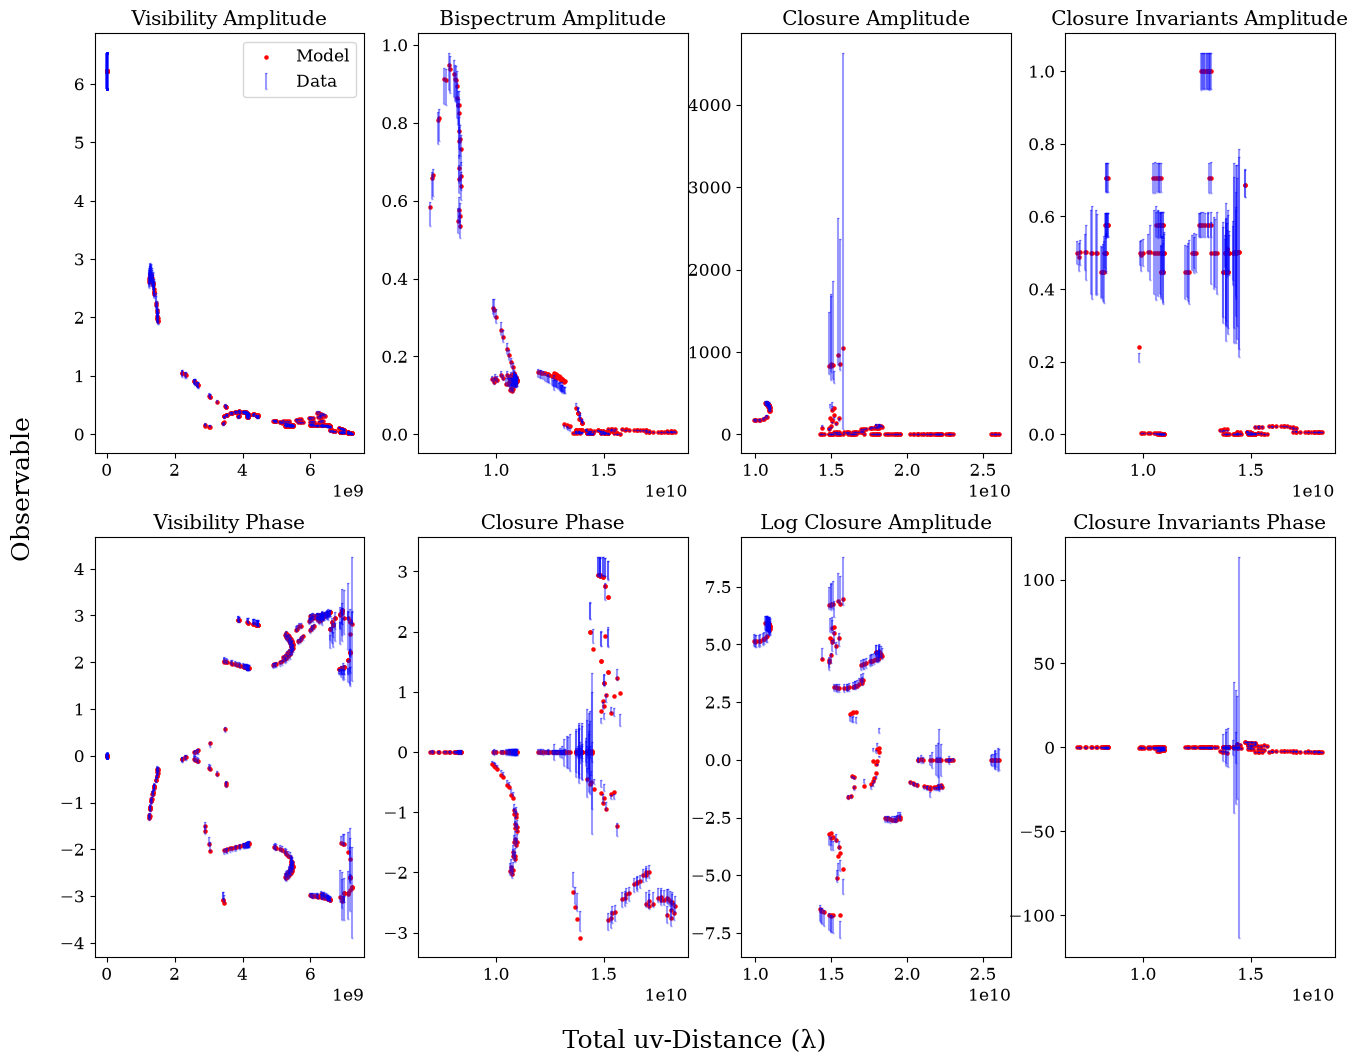

In [4]:
# Likelihood, check all match
noise_factor = 1
static_noise_floor = 0.0001
noise_frac = 0.05
custom_likelihood = likelihood.ModelLikelihood(model_names=model_choice.model_list, obs=obs, count='min', imgdim=imgdim, fov=fov,
                                               noise_factor=noise_factor, static_noise_floor=static_noise_floor, noise_frac=noise_frac)

custom_likelihood.plot_all(model_choice.params)
